In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

ping_file = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/fact_ping.csv'
probes_file = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_probe.csv'
sites_file = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_site.csv'

In [3]:
sites = pd.read_csv(sites_file)
probes = pd.read_csv(probes_file)
pings = pd.read_csv(ping_file)

pings.sample(20)

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id
2873,2874,2026-06-14T17:25:43+00:00,7613,3,152605,3,0,100.0,NaN,NaN,NaN,180055857
21332,21333,2026-06-15T12:41:02+00:00,1015679,9,136174,3,3,0.0,172.176239,172.401903,172.516512,180055901
24184,24185,2026-06-15T16:05:58+00:00,1015679,9,136174,3,3,0.0,228.221918,237.415587,246.110140,180055901
273,274,2026-06-14T14:41:43+00:00,7613,2,152605,3,3,0.0,17.229671,17.420300,17.622050,180055866
24152,24153,2026-06-15T16:02:21+00:00,7764,9,17557,3,0,100.0,NaN,NaN,NaN,180055901
11779,11780,2026-06-15T02:41:34+00:00,7613,5,152605,3,0,100.0,NaN,NaN,NaN,180055862
41375,41376,2026-06-16T12:40:19+00:00,1016126,3,17557,3,0,100.0,NaN,NaN,NaN,180055857
205,206,2026-06-14T14:37:04+00:00,1016126,4,17557,3,1,66.7,274.431280,274.431280,274.431280,180055874
39604,39605,2026-06-16T10:31:42+00:00,1016126,7,17557,3,3,0.0,211.712197,212.105307,212.654964,180055883
33744,33745,2026-06-16T03:31:22+00:00,7764,2,17557,3,0,100.0,NaN,NaN,NaN,180055866


In [5]:
pings_filtered = pings[pings['loss_pct'] != 100.0]
pings_filtered.sample(20)

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id
6958,6959,2026-06-14T21:40:52+00:00,60223,8,23674,3,3,0.0,196.443121,196.848091,197.206230,180055896
4534,4535,2026-06-14T19:07:38+00:00,62224,7,38193,3,3,0.0,224.732174,226.176366,228.108098,180055883
32223,32224,2026-06-16T01:42:12+00:00,1016036,2,9541,3,3,0.0,24.876851,24.986798,25.170183,180055866
6760,6761,2026-06-14T21:27:25+00:00,7613,7,152605,3,3,0.0,218.863949,218.904521,218.953497,180055883
9337,9338,2026-06-15T00:07:41+00:00,7613,6,152605,3,3,0.0,19.242848,19.303588,19.382458,180055869
11686,11687,2026-06-15T02:36:11+00:00,60223,1,23674,3,3,0.0,101.356217,101.472894,101.660724,180055880
28416,28417,2026-06-15T21:10:14+00:00,60223,6,23674,3,3,0.0,3.283823,3.551794,3.689860,180055869
21845,21846,2026-06-15T13:17:06+00:00,1015679,4,136174,3,3,0.0,119.964547,122.857883,126.345136,180055874
26092,26093,2026-06-15T18:21:44+00:00,1016126,10,17557,2,2,0.0,271.914503,274.381632,276.848760,180055876
34812,34813,2026-06-16T04:47:25+00:00,60223,2,23674,3,3,0.0,3.170691,3.331666,3.457277,180055866


In [6]:
ping_by_probe = pings_filtered.groupby('probe_id')
ping_by_probe.sample(10)

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id
23443,23444,2026-06-15T15:11:44+00:00,7613,2,152605,3,3,0.0,18.191309,18.292150,18.434505,180055866
23556,23557,2026-06-15T15:20:47+00:00,7613,1,152605,2,2,0.0,96.315841,96.437630,96.559419,180055880
36381,36382,2026-06-16T06:40:43+00:00,7613,1,152605,3,3,0.0,94.731715,94.921213,95.250017,180055880
8552,8553,2026-06-14T23:20:38+00:00,7613,1,152605,3,3,0.0,96.168833,96.270643,96.444858,180055880
40335,40336,2026-06-16T11:25:32+00:00,7613,8,152605,3,3,0.0,130.211141,130.269228,130.305061,180055896
...,...,...,...,...,...,...,...,...,...,...,...,...
5750,5751,2026-06-14T20:25:38+00:00,1016143,7,9541,3,3,0.0,203.373751,204.109377,204.596930,180055883
2853,2854,2026-06-14T17:22:38+00:00,1016143,9,9541,3,3,0.0,153.968579,154.232052,154.430612,180055901
10512,10513,2026-06-15T01:22:05+00:00,1016143,2,9541,3,3,0.0,5.025688,5.137303,5.227355,180055866
11554,11555,2026-06-15T02:27:12+00:00,1016143,2,9541,3,3,0.0,5.246945,5.342483,5.500435,180055866


In [8]:
ping_by_probe_by_site = pings_filtered.groupby(['probe_id','site_id'])

In [16]:
g1 = ping_by_probe_by_site.get_group((7613, 1))
g1

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id
12,13,2026-06-14T14:25:45+00:00,7613,1,152605,3,3,0.0,95.338634,95.528062,95.842724,180055880
93,94,2026-06-14T14:30:45+00:00,7613,1,152605,3,3,0.0,95.284741,95.383026,95.548734,180055880
242,243,2026-06-14T14:40:44+00:00,7613,1,152605,2,2,0.0,95.378032,95.378991,95.379950,180055880
326,327,2026-06-14T14:45:52+00:00,7613,1,152605,3,3,0.0,95.190441,95.344684,95.516339,180055880
403,404,2026-06-14T14:50:43+00:00,7613,1,152605,3,3,0.0,97.457770,97.600017,97.800429,180055880
...,...,...,...,...,...,...,...,...,...,...,...,...
42434,42435,2026-06-16T13:55:51+00:00,7613,1,152605,3,3,0.0,94.614836,94.697675,94.791767,180055880
42488,42489,2026-06-16T14:00:38+00:00,7613,1,152605,2,1,50.0,95.354193,95.354193,95.354193,180055880
42626,42627,2026-06-16T14:10:48+00:00,7613,1,152605,3,2,33.3,94.581319,94.626575,94.671831,180055880
42695,42696,2026-06-16T14:15:42+00:00,7613,1,152605,2,2,0.0,94.679065,94.855715,95.032365,180055880


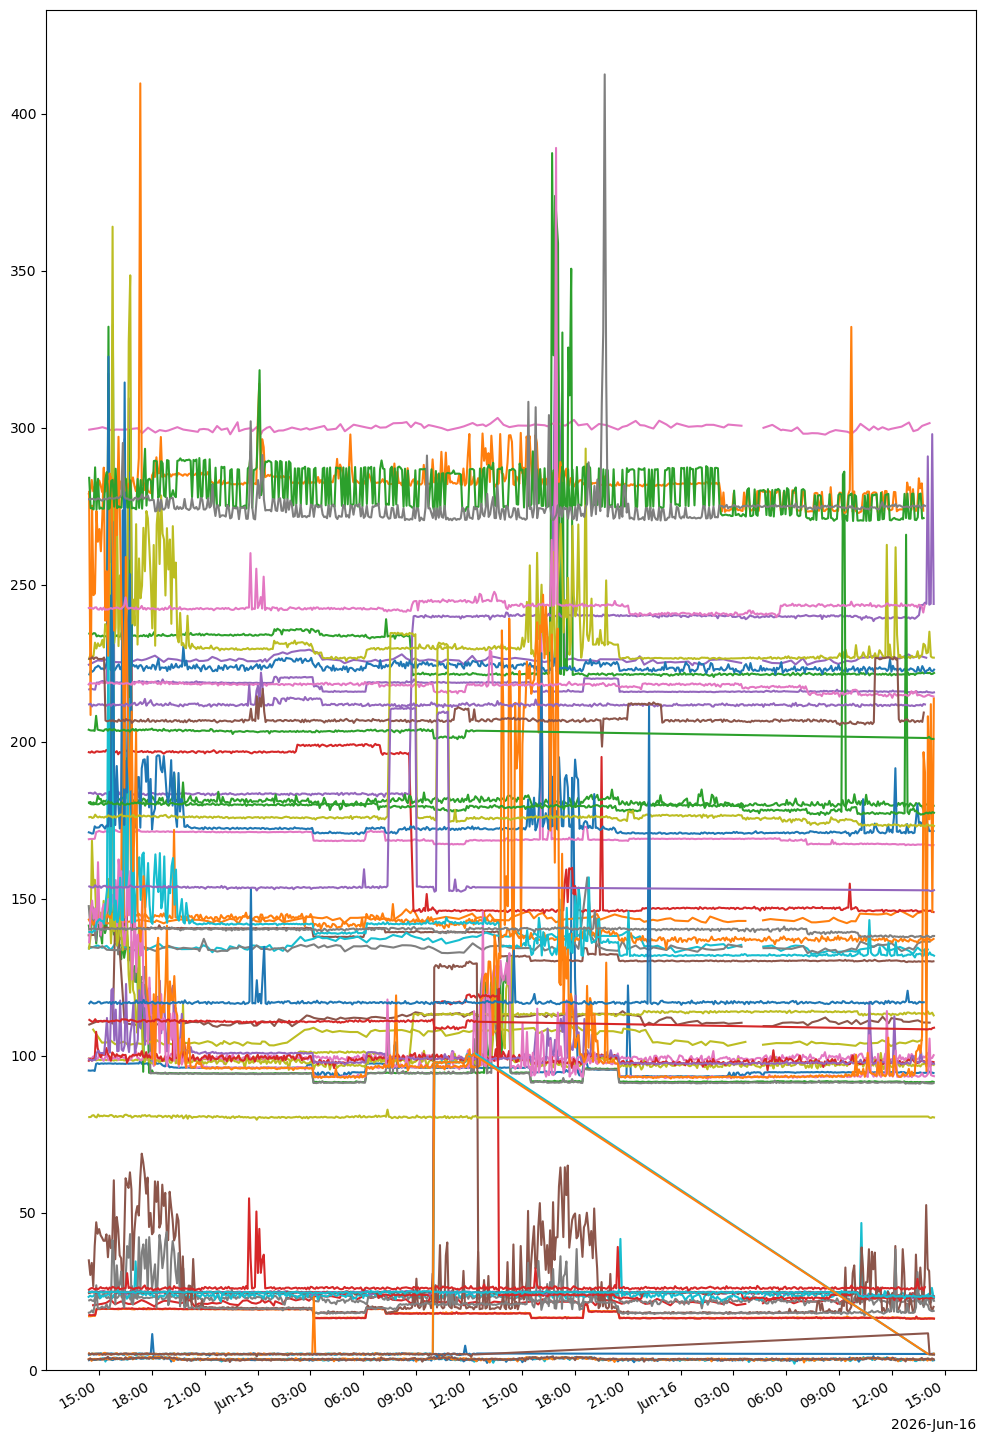

In [43]:
fig, ax = plt.subplots(figsize=(12, 20))

for (probe, site), group in ping_by_probe_by_site:
    x = pd.to_datetime(group['ping_time'])
    y = group['rtt_min']
    ax.plot(x, y)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.ylim(bottom=0) 
fig.autofmt_xdate()

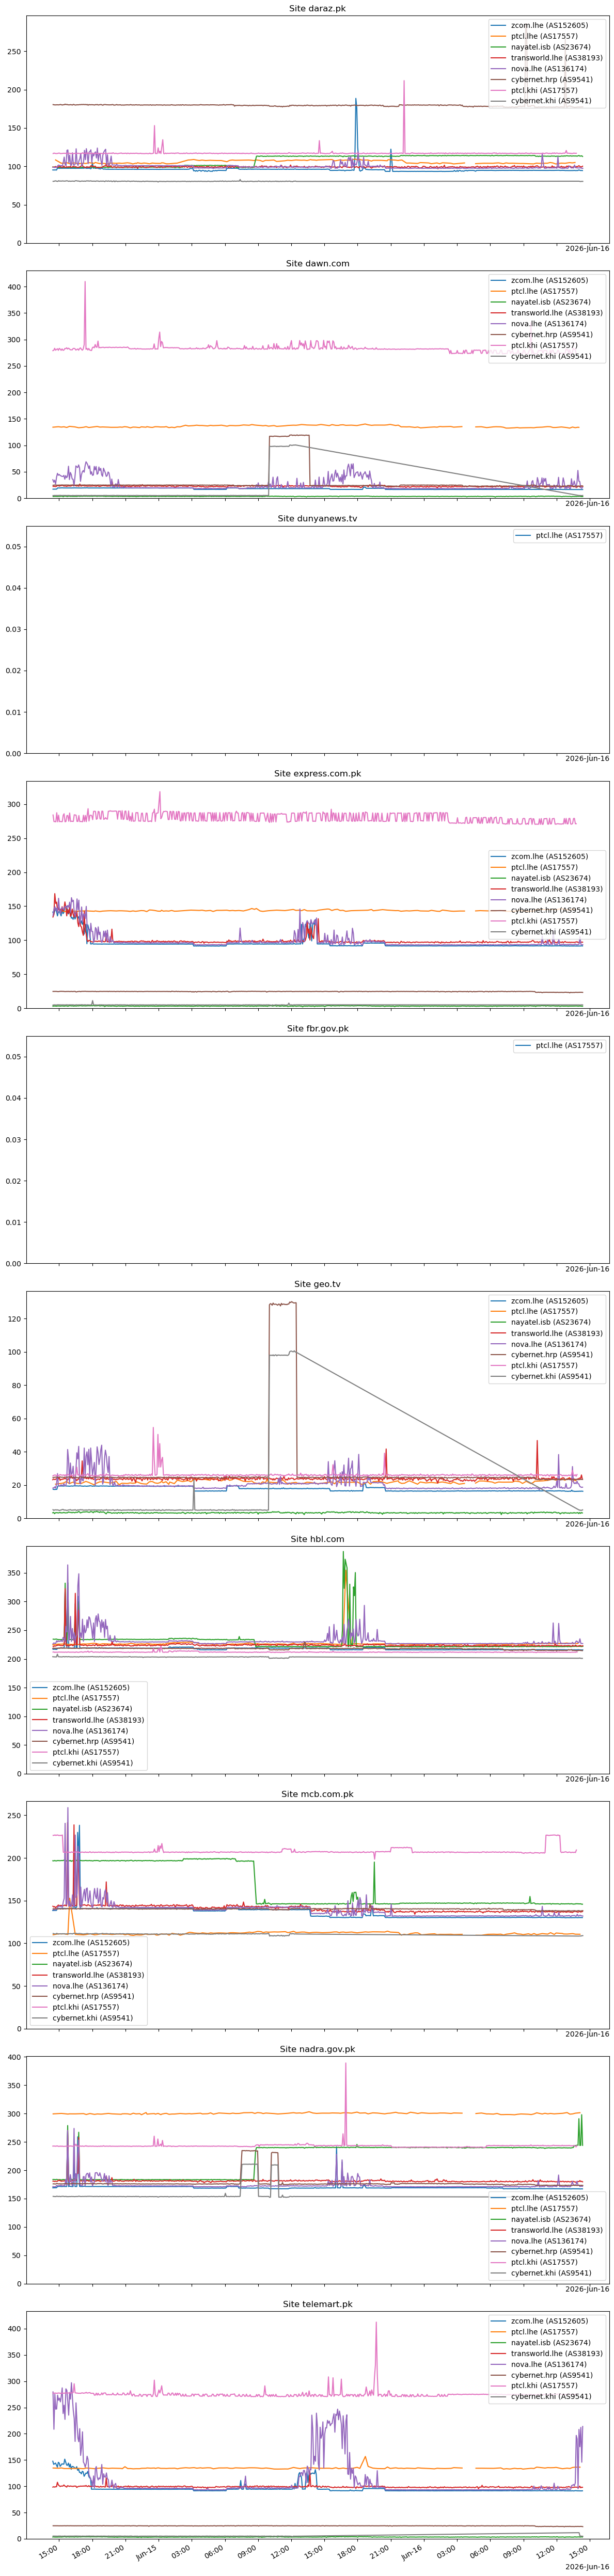

In [72]:
n_sites = sites.shape[0]

fig, axes = plt.subplots(n_sites, 1, figsize=(12, 5 * n_sites), sharex = True)

if n_sites == 1:
    axes = [axes]
    
for ax, site in zip(axes, sites['site_id']):
    site_data = pings_filtered[pings_filtered['site_id'] == site]
    site_name = sites[sites["site_id"] == site]["target_hostname"].values[0]
    
    for probe, group in site_data.groupby('probe_id'):
        probe_name = probes[probes['probe_id'] == probe]['label'].values[0]
        x = pd.to_datetime(group['ping_time'])
        y = group['rtt_min']
        ax.plot(x, y, label=f'{probe_name}')
    
    ax.set_title(f'Site {site_name}')
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.tick_params(labelbottom=True)
    ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [61]:
sites[sites['site_id'] == 1]['target_hostname'].values[0]

'daraz.pk'

In [51]:
sites

,site_id,target_label,target_hostname,target_category
0,1,Daraz,daraz.pk,ecommerce
1,2,Dawn,dawn.com,news
2,3,Dunya News,dunyanews.tv,news
3,4,Express,express.com.pk,news
4,5,FBR,fbr.gov.pk,government
5,6,Geo TV,geo.tv,news
6,7,HBL Bank,hbl.com,banking
7,8,MCB Bank,mcb.com.pk,banking
8,9,NADRA,nadra.gov.pk,government
9,10,Telemart,telemart.pk,ecommerce


## TODO: Check out 
Site ID 10 for probe ID 1015679, June 14 3 pm to 6 pm, then 6 pm to June 15 12 pm. June 15 2 pm to 6 pm.

Site ID 9 from probe ID 1016143 on June 15 9 am to 10 am

Site ID 8 from probe ID 60223 on June 14 till June 15 9 am

Site ID 6 from probe IDs 1016036 and 1016143 on June 15 from 10 am to 1 pm

Site ID 3 from probe IDs 1016036 and 1016143 on June 15 from 10 am to 1 pm

Site ID 1 June 15 9 am onwards for probe ID 60223


In [74]:
import re
def pat_dest(test):
    pattern = r'([\w.-]+\.[a-z.]+)\s+-\s+([\w\s]+?)\s+\(([\w\s]+)\)'
    match = re.search(pattern, test)
    if match:
        url, name, category = match.groups()
    else:
        print(f'{test} not matched')
    return (url, name, category)

def pat_time(test):
    pattern = r'\w+\s+(\d{4})-(\d{2})-(\d{1,2})t(\d{2}:\d{1,2}:\d{2})(\+\d{2}:\d{2})'
    match = re.search(pattern, test)
    if match:
        (year, month, day, time, tz) = match.groups()
    else:
        print(f'{test} not matched')
    return (year, month, day, time, tz)
    
def read_trace(f, trace_id, sites, probes):
    # The next line contains the site URL, name and category    
    next = f.readline()
    (site_url, site, category) = pat_dest(next.strip().lower())
    site_id = sites.index[sites['target_hostname'] == site_url]
    # tokens = next.split('-')
    # site_url = tokens[0].strip()
    # tokens = tokens[1].split()
    # site = tokens[0].strip()
    # category = tokens[1].strip()
    
    # The next line contains time
    next = f.readline()
    (year, month, day, time, tz) = pat_time(next.strip().lower())
    # tokens = next.split()
    # time = tokens[1]
    # tokens = tokens[1].split('T')
    # date = tokens[0]
    # time_str = tokens[1]
    
    # The next line contains source probe information
    next = f.readline()
    tokens = next.split('-')
    probe_id = tokens[0].split()[2]
    probe_asn = tokens[1].strip()
    probe_name = tokens[2].strip()
    src = probe_id
    # src = " ".join(tokens[6:])
    
    # The next line contains the destination information
    next = f.readline()
    tokens = next.split()
    dest = " ".join(tokens[1:])
    # The next line is blank
    f.readline()
    # The next line has a long --- string
    f.readline()

    tf = pd.DataFrame({'trace_id': trace_id, 'site_id': site_id,  
                       'year': year, 'month': month, 'day': day, 'time': time, 'timezone': tz, 
                      'probe_id': probe_id, 'dest': dest}, index=[0])
    # The next lines contain the traceroute hop by hop
    next = f.readline()
    # hop_numbers = []
    # hop_ips = []
    # hop_rtt = []
    hop_records = []
    while len(next) > 1:
        tokens = next.split()
        row = {
            'trace_id': trace_id,
            'hop_number': tokens[0],
            'hop_rtt': tokens[1],
            'hop_ip': tokens[2]
        }
        hop_records.append(row)
        # hop_numbers.append(tokens[0])
        # hop_rtt.append(tokens[1])
        # hop_ips.append(tokens[2])
        
        next = f.readline()
    df = pd.DataFrame(hop_records)
    # return (site, time, src, dest, hop_numbers, hop_ips, hop_rtt)
    return tf, df
    
def load_data_file(file_path, sites, probes):
    data = []
    trace_id = 0
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            master_hops = []
            master_trace_ids = []
            # The first line contains the header. Skip it
            f.readline()
            # The second line contains the number of traces. Save it somewhere
            next = f.readline()
            tokens = next.split()
            count = tokens[0]
            # The next line is blank
            f.readline()
            # The next line has a long ==== string
            f.readline()
            done = False
            while not done:
                tf, df = read_trace(f, trace_id, sites, probes)
                master_hops.append(df)
                master_trace_ids.append(tf)
                # data.append(tup)
                trace_id += 1
                if not f.readline():
                    done = True
            # 1. Use pd.concat for the list of hop dataframes
            df_hops = pd.concat(master_hops, ignore_index=True) if master_hops else pd.DataFrame()
            
            # 2. Use pd.concat for the trace metadata dataframes too (since they are now 2D with index=[0])
            df_traces = pd.concat(master_trace_ids, ignore_index=True) if master_trace_ids else pd.DataFrame()
                
    except Exception as e:
        print(f"Error reading file in background thread: {e}")
    df_traces = df_traces.set_index('trace_id', drop=True)
    return df_traces, df_hops

file_path = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/routes_20260616_142719.txt'
df_traces, df_hops = load_data_file(file_path, sites, probes)

In [75]:
df_traces.head()

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,0,2026,06,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,0,2026,06,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,0,2026,06,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,0,2026,06,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,0,2026,06,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...


In [88]:
set_1 = df_traces[df_traces['site_id'] == 9] 
# set_1 = set_1[set_1['probe_id'] == 1015679]

In [91]:
set_1[set_1['probe_id'] == '1015679']

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
12894,9,2026,06,14,14:31:28,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12901,9,2026,06,14,14:46:29,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12909,9,2026,06,14,15:01:19,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12918,9,2026,06,14,15:16:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12925,9,2026,06,14,15:31:23,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
...,...,...,...,...,...,...,...,...
14289,9,2026,06,16,13:16:30,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14297,9,2026,06,16,13:31:31,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14303,9,2026,06,16,13:46:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
